### **Classificatie pipeline: TEDx Dataset**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import nltk
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import cross_val_score
import pickle
import re
import matplotlib.pyplot as plt

#### **Data inladen**


In [2]:
df = pd.read_csv('studentset.csv')
df.head()

,transcript,label
0,So when I was a kid ... this was my team.(Laug...,1
1,This is how war starts. One day you're living ...,0
2,"In the next 18 minutes, I'm going to take you ...",1
3,"Before March, 2011, I was a photographic retou...",0
4,Chris Anderson: And now we go live to Caracas ...,1


#### **Data opschonen**

Ik haal de speciale tekens en nummers uit de transcripts. Daarbij haal ik ook de woorden tussen haakjes (zoals laughter, music, applause) eruit, omdat deze niet relevant zijn voor de sentiment score. 

In [3]:
def preprocess_text(text):
    # Remove text within square brackets
    text = re.sub(r'\[[^\]]*\]', ' ', text)

    # Remove text within parentheses
    text = re.sub(r'\([^)]*\)', ' ', text)

    # Remove text within angle brackets
    text = re.sub(r'<[^>]*>', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # Replace multiple newlines with a single space
    text = re.sub(r'\n+', ' ', text)

    # Remove all numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

df['clean_transcript'] = df['transcript'].apply(preprocess_text)

In [4]:
df['clean_transcript'].head()

0    so when i was a kid this was my team i stunk a...
1    this is how war starts one day you re living y...
2    in the next minutes i m going to take you on a...
3    before march i was a photographic retoucher ba...
4    chris anderson and now we go live to caracas t...
Name: clean_transcript, dtype: object

#### **Visualisatie**

Text(0.5, 1.0, 'Verdeling van de Labels')

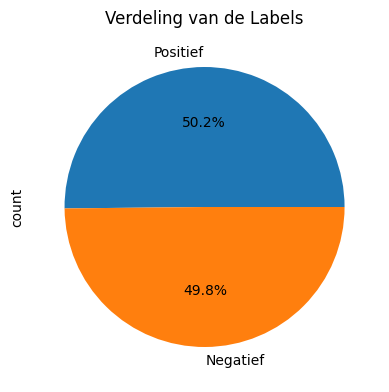

In [5]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Positief', 'Negatief'])
plt.title('Verdeling van de Labels')


### **Train/test split**
De dataset wordt nu opgesplitst in een train set en een test set  

In [6]:
features = df['clean_transcript']
label = df['label']

grootte_testset = 0.2
X_train, X_test, y_train, y_test = train_test_split (features, label,test_size=grootte_testset ,stratify=label)

### **Bag of Words**
Voor het Bag of Words model is er gekozen voor de TFIDF vectorizer. Hierdoor krijgen belangrijke woorden meer gewicht. Belangrijke woorden in dit geval zijn woorden die bijvoorbeeld vaak voorkomen in een transcript, maar zeldzaam zijn in de rest van de data. Minder belangrijke woorden (woorden die veel voorkomen zoals 'the', 'people', 'talk', etcetera) krijgen minder gewicht.

In [7]:
tfidf = TfidfVectorizer(
    stop_words='english',
    min_df=1,
    max_df=0.9,
    max_features=50000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### **Classificeren**
Er is gekozen voor het model Naive Bayes voor classificatie. Naive Bayes is goed bestand tegen irrelevante tekst en over het algemeen snel en effectief te trainen voor tekstanalyse. 

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred = nb_model.predict(X_test_tfidf)

### **Validatie**
We berekenen de accuracy door de predicties van de testset te vergelijken met de echte labels. Ook maken we een confusion matrix die een totaal overzicht geeft van alle voorspellingen. 

### **Benchmarken** 

In [9]:
print("\nPerformance Metrics Berekening:")
print("================================")

n_iterations = 1000 
latencies = []

for _ in range(n_iterations):
    start_ts = time.time()
    nb_model.predict(X_test_tfidf[0:1])
    end_ts = time.time()
    latencies.append(end_ts - start_ts)

# Bereken gemiddelde latency
avg_latency = np.mean(latencies)
print(f"Gemiddelde Latency: {avg_latency:.6f} seconden")

start_ts = time.time()
nb_model.predict(X_test_tfidf[:1000])
end_ts = time.time()
total_time = end_ts - start_ts
throughput = 1000 / total_time
print(f"Throughput: {throughput:.4f} voorspellingen per seconde")
print(f"Throughput in milliseconden: {(1/throughput)*1000:.4f} ms per voorspelling")

# Accuracy metrics
y_pred = nb_model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")

# Vergelijk met benchmark
print("\nVergelijking met Benchmark:")
print("=========================")
benchmark_ml = {
    'Latency': 0.709347838,    # seconds
    'Throughput': 0.6385,      # milliseconds
    'Accuracy': 0.655540929,
    'Precision': 0.648788055,
    'Recall': 0.689175306
}

print(f"Latency - Dit model: {avg_latency:.6f}s vs Benchmark: {benchmark_ml['Latency']}s")
print(f"Throughput - Dit model: {(1/throughput)*1000:.4f}ms vs Benchmark: {benchmark_ml['Throughput']}ms")
print(f"Accuracy - Dit model: {accuracy:.6f} vs Benchmark: {benchmark_ml['Accuracy']}")
print(f"Precision - Dit model: {precision:.6f} vs Benchmark: {benchmark_ml['Precision']}")
print(f"Recall - Dit model: {recall:.6f} vs Benchmark: {benchmark_ml['Recall']}")



Performance Metrics Berekening:
Gemiddelde Latency: 0.000446 seconden
Throughput: 398546.5602 voorspellingen per seconde
Throughput in milliseconden: 0.0025 ms per voorspelling

Model Performance Metrics:
Accuracy: 0.672973
Precision: 0.675030
Recall: 0.672973

Vergelijking met Benchmark:
Latency - Jouw model: 0.000446s vs Benchmark: 0.709347838s
Throughput - Jouw model: 0.0025ms vs Benchmark: 0.6385ms
Accuracy - Jouw model: 0.672973 vs Benchmark: 0.655540929
Precision - Jouw model: 0.675030 vs Benchmark: 0.648788055
Recall - Jouw model: 0.672973 vs Benchmark: 0.689175306


#### Confusion Matrix
Met de accuraatheid score van de classificatie, kan er nu worden gekeken naar de resultaten in een Confusion Matrix.

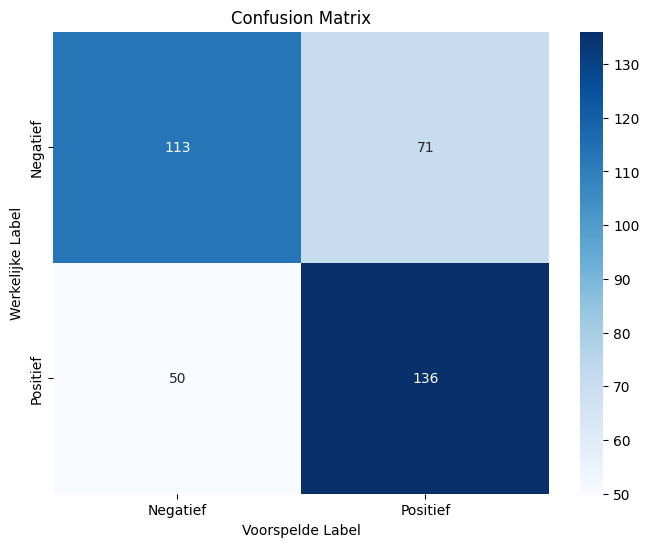

In [10]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatief', 'Positief'],
            yticklabels=['Negatief', 'Positief'])
plt.title('Confusion Matrix')
plt.ylabel('Werkelijke Label')
plt.xlabel('Voorspelde Label')
plt.show()

In [11]:
print("\nConfusion Matrix:")
print(f"True Negatives: {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives: {cm[1][1]}")


Confusion Matrix:
True Negatives: 113
False Positives: 71
False Negatives: 50
True Positives: 136


Zoals duidelijk wordt gemaakt hierboven, staat het gros van de resultaten in True positives en True negatives. Een deel zijn nog wel False positives en False negatives. Om dit aantal kleiner te houden, zijn de configuraties van het nlp model (tfidf) zo aangepast dat er iets meer ram wordt vereist, maar dat er wel naar meer woorden wordt gekeken. De max_features staan op 50.000. Min_df stond in eerste instantie op drie, wat betekent dat woorden die in drie transcripts of minder staan worden genegeerd, maar dat is verkleind naar 1. 

### **Opslaan model**
Het model wordt opgeslagen voor toekomstig gebruik

In [12]:
joblib.dump(tfidf, 'nlp_model.joblib')
joblib.dump(nb_model, 'classification.joblib')